# Metrics and Evaluation

This notebook demonstrates the evaluation functionalities available in **3W Toolkit**.

We will simulate the output of a trained classifier and use those results to demonstrate:

- classification metrics;
- multiclass evaluation and averaging strategies;
- sample weights;
- confusion matrix visualization;
- feature importance visualization.

The training step is intentionally omitted so that the workshop can focus on the toolkit's assessment functionality.


## Learning goals

By the end of this notebook, you should be able to:

- obtain `y_true`, `y_pred`, and `y_proba` from a model evaluation workflow;
- choose appropriate metrics for multiclass classification;
- understand the difference between hard predictions and continuous scores;
- use `sample_weight` when required by an evaluation protocol;
- visualize model predictions with `AssessmentVisualization`.


## 📋 Table of Contents

1. [Setup](#setup)
2. [Preparing evaluation results](#preparing-evaluation-results)
3. [Classification metrics](#classification-metrics)
4. [Score-based metrics](#score-based-metrics)
5. [Sample weights](#sample-weights)
6. [Assessment visualizations](#assessment-visualizations)
7. [Evaluation summary](#evaluation-summary)
8. [Next steps](#next-steps)


---

## 1. Setup <a id="setup"></a>

We import the metrics from `ThreeWToolkit.metrics` and the assessment visualizations from `ThreeWToolkit.assessment`.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ThreeWToolkit.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
    roc_auc_score,
)

from ThreeWToolkit.assessment.assessment_visualizations import (
    AssessmentVisualization,
    AssessmentVisualizationConfig,
)

# Fix seed for experiments
np.random.seed(42)


---

## 2. Preparing evaluation results <a id="preparing-evaluation-results"></a>

In a complete training workflow, these values would be obtained after inference on the test set. For this workshop, we mock them directly.

For multiclass classification we distinguish:

- `y_true`: ground-truth class labels;
- `y_pred`: hard class predictions, obtained from the model output using `argmax`;
- `y_proba`: class probabilities produced by the model, obtained after applying softmax to the logits.

Metrics based on the final predicted classes use `y_pred`, while **average precision** and **ROC AUC** require continuous scores such as `y_proba`.


In [2]:
n_samples = 300
num_classes = 3

y_true = np.random.choice(
    [0, 1, 2],
    size=n_samples,
    p=[0.20, 0.55, 0.25],
)

# Generate probabilities mostly concentrated on the true class
y_proba = np.full((n_samples, num_classes), 0.15)

for i, label in enumerate(y_true):
    if np.random.rand() < 0.10:
        # Ambiguous / difficult sample
        y_proba[i, label] = 0.30
        y_proba[i, np.random.choice([c for c in range(num_classes) if c != label])] = 0.55
    else:
        y_proba[i, label] = 0.70

y_proba /= y_proba.sum(axis=1, keepdims=True)

y_pred = np.argmax(y_proba, axis=1)

print(f"Number of samples: {len(y_true)}")
print(f"Number of classes: {num_classes}")
print(f"y_true shape: {y_true.shape}")
print(f"y_pred shape: {y_pred.shape}")
print(f"y_proba shape: {y_proba.shape}")

Number of samples: 300
Number of classes: 3
y_true shape: (300,)
y_pred shape: (300,)
y_proba shape: (300, 3)


A few predictions make the distinction clearer. `y_pred` contains one class label per sample, whereas each row of `y_proba` contains one score for every class.


In [3]:
pd.DataFrame(
    {
        "y_true": y_true[:10],
        "y_pred": y_pred[:10],
        "prob_class_0": y_proba[:10, 0],
        "prob_class_1": y_proba[:10, 1],
        "prob_class_2": y_proba[:10, 2],
    }
)


,y_true,y_pred,prob_class_0,prob_class_1,prob_class_2
0,1,2,0.15,0.30,0.55
1,2,2,0.15,0.15,0.70
2,1,1,0.15,0.70,0.15
3,1,1,0.15,0.70,0.15
4,0,0,0.70,0.15,0.15
5,0,0,0.70,0.15,0.15
6,0,0,0.70,0.15,0.15
7,2,1,0.15,0.55,0.30
8,1,1,0.15,0.70,0.15
9,1,1,0.15,0.70,0.15


---

## 3. Classification metrics <a id="classification-metrics"></a>

The first group contains metrics that evaluate the final predicted classes. They operate on `y_true` and `y_pred`.

| Metric | Main idea |
| --- | --- |
| `accuracy_score` | Fraction of correct predictions |
| `balanced_accuracy_score` | Average recall across classes |
| `precision_score` | Correctness of positive predictions |
| `recall_score` | Fraction of each class correctly detected |
| `f1_score` | Harmonic mean of precision and recall |
| `matthews_corrcoef` | Correlation between true and predicted classes |


### Accuracy and balanced accuracy

`accuracy_score` measures the overall fraction of correct predictions. `balanced_accuracy_score` gives each class equal importance by averaging the recall obtained on each class.


In [4]:
accuracy = accuracy_score(y_true=y_true, y_pred=y_pred)
balanced_accuracy = balanced_accuracy_score(y_true=y_true, y_pred=y_pred)

print(f"Accuracy: {accuracy:.3f}")
print(f"Balanced accuracy: {balanced_accuracy:.3f}")


Accuracy: 0.873
Balanced accuracy: 0.867


### Precision, recall, and F1

For multiclass problems, the toolkit supports the usual averaging strategies.

- `None`: returns one value per class;
- `macro`: unweighted mean across classes;
- `weighted`: mean weighted by class support.


In [5]:
precision_per_class = precision_score(
    y_true=y_true, y_pred=y_pred, average=None
)
recall_per_class = recall_score(
    y_true=y_true, y_pred=y_pred, average=None
)
f1_per_class = f1_score(
    y_true=y_true, y_pred=y_pred, average=None
)

metric_by_class = pd.DataFrame(
    {
        "Precision": precision_per_class,
        "Recall": recall_per_class,
        "F1": f1_per_class,
    },
    index=[f"Class {i}" for i in range(num_classes)],
)

metric_by_class


,Precision,Recall,F1
Class 0,0.774648,0.833333,0.802920
Class 1,0.939597,0.886076,0.912052
Class 2,0.837500,0.881579,0.858974


In [6]:
precision_macro = precision_score(y_true=y_true, y_pred=y_pred, average="macro")
precision_weighted = precision_score(y_true=y_true, y_pred=y_pred, average="weighted")

recall_macro = recall_score(y_true=y_true, y_pred=y_pred, average="macro")
recall_weighted = recall_score(y_true=y_true, y_pred=y_pred, average="weighted")

f1_macro = f1_score(y_true=y_true, y_pred=y_pred, average="macro")
f1_weighted = f1_score(y_true=y_true, y_pred=y_pred, average="weighted")

pd.DataFrame(
    {
        "Metric": [
            "Precision (macro)",
            "Precision (weighted)",
            "Recall (macro)",
            "Recall (weighted)",
            "F1 (macro)",
            "F1 (weighted)",
        ],
        "Value": [
            precision_macro,
            precision_weighted,
            recall_macro,
            recall_weighted,
            f1_macro,
            f1_weighted,
        ],
    }
)


,Metric,Value
0,Precision (macro),0.850582
1,Precision (weighted),0.877444
2,Recall (macro),0.866996
3,Recall (weighted),0.873333
4,F1 (macro),0.857982
5,F1 (weighted),0.874597


### Matthews correlation coefficient

`matthews_corrcoef` provides a correlation-based summary of the agreement between the true and predicted classes.

The coefficient ranges from:

* **+1** → Perfect prediction
* **0** → Performance no better than random guessing
* **−1** → Complete disagreement between predictions and true labels

In [7]:
mcc = matthews_corrcoef(y_true=y_true, y_pred=y_pred)

print(f"Matthews correlation coefficient: {mcc:.3f}")


Matthews correlation coefficient: 0.796


---

## 4. Score-based metrics <a id="score-based-metrics"></a>

Some metrics evaluate the model's ranking or confidence across different decision thresholds. These metrics should receive **continuous scores**, not `argmax` predictions.

The toolkit provides:

- `average_precision_score` for precision-recall performance;
- `roc_auc_score` for ROC-based performance.

For multiclass problems, the `average` and `multi_class` parameters define how the per-class results are aggregated.


### Average precision

Average precision summarizes the precision-recall curve over different decision thresholds. We pass `y_proba` rather than `y_pred` so that the metric can use the complete ranking information from the classifier.


In [8]:
average_precision = average_precision_score(
    y_true=y_true,
    y_pred=y_proba,
    average="weighted",
    num_classes=num_classes,
)

print(f"Weighted average precision: {average_precision:.3f}")


Weighted average precision: 0.985


### ROC AUC

ROC AUC measures the area under the ROC curve. For multiclass classification, the toolkit supports both **one-vs-rest (`ovr`)** and **one-vs-one (`ovo`)** formulations.


In [9]:
roc_auc_ovr = roc_auc_score(
    y_true=y_true,
    y_pred=y_proba,
    average="macro",
    multi_class="ovr",
    num_classes=num_classes,
)

roc_auc_ovo = roc_auc_score(
    y_true=y_true,
    y_pred=y_proba,
    average="macro",
    multi_class="ovo",
    num_classes=num_classes,
)

print(f"Macro ROC AUC (OVR): {roc_auc_ovr:.3f}")
print(f"Macro ROC AUC (OVO): {roc_auc_ovo:.3f}")


Macro ROC AUC (OVR): 0.992
Macro ROC AUC (OVO): 0.992


---

## 5. Sample weights <a id="sample-weights"></a>

Most metrics in the toolkit accept `sample_weight`. This allows individual samples to contribute with different importance during evaluation.

For example, we can assign a weight of `2` to samples belonging to class `0` and keep the default weight of `1` for the remaining samples.


In [10]:
sample_weight = np.ones(len(y_true))
sample_weight[y_true == 0] = 2

accuracy_weighted = accuracy_score(
    y_true=y_true,
    y_pred=y_pred,
    sample_weight=sample_weight,
)

f1_weighted_samples = f1_score(
    y_true=y_true,
    y_pred=y_pred,
    average="weighted",
    sample_weight=sample_weight,
)

print(f"Accuracy with sample weights: {accuracy_weighted:.3f}")
print(f"Weighted F1 with sample weights: {f1_weighted_samples:.3f}")


Accuracy with sample weights: 0.866
Weighted F1 with sample weights: 0.866


---

## 6. Assessment visualizations <a id="assessment-visualizations"></a>

Metrics provide numerical summaries, while visualizations help us inspect model behavior directly.

`AssessmentVisualization` provides reusable plots for model assessment. The same class can be configured once and reused for different evaluation results.


### Confusion matrix

A confusion matrix shows how the true classes are distributed across the predicted classes. It is especially useful for identifying which classes are being confused by the model.

The visualization accepts common Python data structures such as lists, NumPy arrays, and pandas Series. Here we use the simulated NumPy arrays.


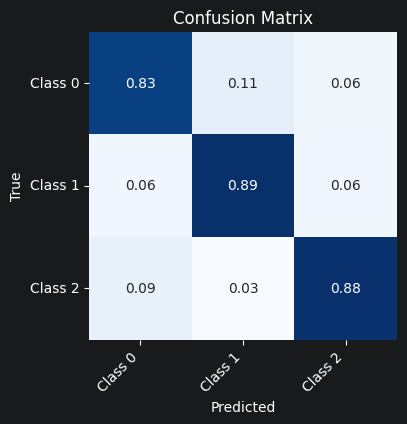

In [11]:
config = AssessmentVisualizationConfig(
    class_names=["Class 0", "Class 1", "Class 2"]
)
visualizer = AssessmentVisualization(config=config)

visualizer.plot_confusion_matrix(
    y_true=y_true,
    y_pred=y_pred,
    figsize=(6, 4),
    title="Confusion Matrix",
    normalize=True,
);


The same visualization can be used with a `pandas.Series`. This is useful when predictions are associated with timestamps, sensor identifiers, or other metadata.


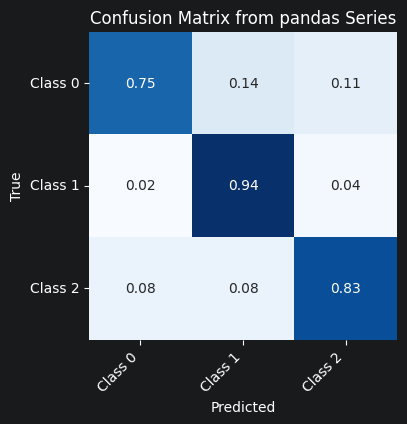

In [12]:
dates = pd.date_range("2023-01-01", periods=100, freq="h")
y_true_series = pd.Series(y_true[:100], index=dates, name="True State")
y_pred_series = pd.Series(y_pred[:100], index=dates, name="Predicted State")

visualizer.plot_confusion_matrix(
    y_true=y_true_series,
    y_pred=y_pred_series,
    figsize=(6, 4),
    title="Confusion Matrix from pandas Series",
);


### Feature importance visualization

`feature_visualization` can display feature importance values produced by a model. The visualization is independent of the estimator, so any model that exposes feature importance values can be used.


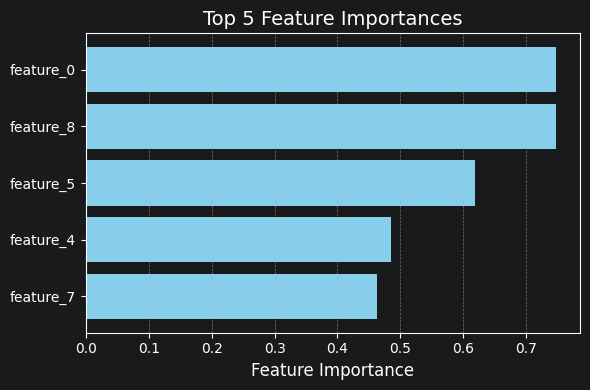

In [13]:
feature_names = [f"feature_{i}" for i in range(10)]
feature_importances = np.random.rand(10)

visualizer.feature_visualization(
    feature_importances=feature_importances,
    feature_names=feature_names,
    top_n=5,
    title="Top 5 Feature Importances",
    figsize=(6, 4),
)
plt.show()


For example, a scikit-learn model can provide its `feature_importances_` attribute directly.


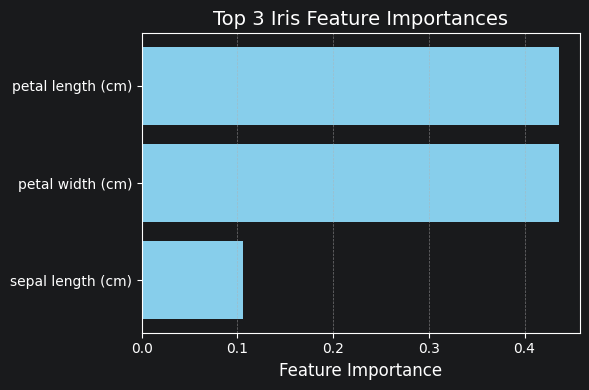

In [14]:
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier

iris = load_iris()
model = RandomForestClassifier(random_state=42).fit(iris.data, iris.target)

visualizer.feature_visualization(
    feature_importances=model.feature_importances_,
    feature_names=iris.feature_names,
    top_n=3,
    title="Top 3 Iris Feature Importances",
    figsize=(6, 4),
)
plt.show()


---

## 7. Evaluation summary <a id="evaluation-summary"></a>

Finally, we can collect the main metrics into a single table. In a real experiment, this table can be stored alongside the model configuration and used to compare different experiments.


In [15]:
evaluation_summary = pd.DataFrame(
    {
        "Metric": [
            "Accuracy",
            "Balanced Accuracy",
            "Precision (macro)",
            "Recall (macro)",
            "F1 (macro)",
            "F1 (weighted)",
            "Average Precision (weighted)",
            "ROC AUC (OVR macro)",
            "MCC",
        ],
        "Value": [
            accuracy,
            balanced_accuracy,
            precision_macro,
            recall_macro,
            f1_macro,
            f1_weighted,
            average_precision,
            roc_auc_ovr,
            mcc,
        ],
    }
)

evaluation_summary


,Metric,Value
0,Accuracy,0.873333
1,Balanced Accuracy,0.866996
2,Precision (macro),0.850582
3,Recall (macro),0.866996
4,F1 (macro),0.857982
5,F1 (weighted),0.874597
6,Average Precision (weighted),0.985230
7,ROC AUC (OVR macro),0.991504
8,MCC,0.796243


### Choosing metrics

There is no single metric that describes every aspect of a classification model. The appropriate set depends on the problem and on the evaluation protocol.

As a practical starting point:

- use **accuracy** for the overall fraction of correct predictions;
- use **balanced accuracy** when class balance matters;
- inspect **precision, recall, and F1** when the type of classification error matters;
- use **average precision** and **ROC AUC** when continuous prediction scores are available;
- use **MCC** as an additional correlation-based summary;
- use the **confusion matrix** to understand which classes are being confused.


---

## 8. Next steps <a id="next-steps"></a>

🎉 **Nice!** You have now seen the main assessment capabilities of **3W Toolkit**.

In a complete workflow, replace the mocked predictions with the outputs of `trainer.predict()` and `trainer.predict_proba()` on a held-out test set. The same metrics and visualizations can then be applied without changing the evaluation logic.

Together with the data visualization and feature extraction notebooks, this provides a complete path from raw data to feature representation, model predictions, and quantitative and visual assessment.

### What's Next?

1. **Report Generation**: Discover how to create comprehensive HTML or LaTeX reports from model evaluation results in [Notebook 10: Generate Report](10_generating_reports.ipynb)
